In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gauravmalik26/food-delivery-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.95M/1.95M [00:00<00:00, 109MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/gauravmalik26/food-delivery-dataset/versions/1


In [ ]:
train = pd.read_csv(path+"/train.csv")
test = pd.read_csv(path+"/test.csv")
df1 = pd.read_csv(path+"/Sample_Submission.csv")

In [ ]:
df = train.copy()

In [ ]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [ ]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [ ]:
df.shape

(45593, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [ ]:
df.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,0


There are null values in the datset but the function isnull is unable to detect it is not numeric but a string. dataset contains disguised missing values—meaning the blanks are stored as strings, whitespace, or special placeholder characters rather than true database/system nulls

#### **Handling Missing Values**

In [ ]:
df.isnull().mean()

,0
ID,0.0
Delivery_person_ID,0.0
Delivery_person_Age,0.0
Delivery_person_Ratings,0.0
Restaurant_latitude,0.0
Restaurant_longitude,0.0
Delivery_location_latitude,0.0
Delivery_location_longitude,0.0
Order_Date,0.0
Time_Orderd,0.0


So here before replacing the null strings with null numeric we have to check out what sort of null string is in the dataset , the NaN value had a whitespace.

In [ ]:
from pandas.core.dtypes import missing
missing_symbols = ["", " ", "NA", "na", "N/A", "null", "NaN ", "?", "-", "NaN"]
df.replace(missing_symbols, np.nan, inplace=True)


In [ ]:
df.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,1854
Delivery_person_Ratings,1908
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1731


In [ ]:
df = df.dropna()

Since the missing values are less than 5% so we can drop them

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41368 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41368 non-null  object 
 1   Delivery_person_ID           41368 non-null  object 
 2   Delivery_person_Age          41368 non-null  object 
 3   Delivery_person_Ratings      41368 non-null  object 
 4   Restaurant_latitude          41368 non-null  float64
 5   Restaurant_longitude         41368 non-null  float64
 6   Delivery_location_latitude   41368 non-null  float64
 7   Delivery_location_longitude  41368 non-null  float64
 8   Order_Date                   41368 non-null  object 
 9   Time_Orderd                  41368 non-null  object 
 10  Time_Order_picked            41368 non-null  object 
 11  Weatherconditions            41368 non-null  object 
 12  Road_traffic_density         41368 non-null  object 
 13  Vehicle_condition    

In [ ]:
df["Weatherconditions"].unique()

array(['conditions Sunny', 'conditions Stormy', 'conditions Sandstorms',
       'conditions Cloudy', 'conditions Fog', 'conditions Windy'],
      dtype=object)

In [ ]:
df["Weatherconditions"] = df["Weatherconditions"].replace({
    "conditions Windy": "Windy",
    "conditions Stormy" : "Stormy",
    "conditions Fog" : "Fog",
    "conditions Sunny" : "Sunny",
    "conditions Cloudy" : "Cloudy",
    "conditions Sandstorms" : "Sandstorms",
    "conditions NaN" : "Normal"
})

In [ ]:
test["Weatherconditions"] = test["Weatherconditions"].replace({
    "conditions Windy": "Windy",
    "conditions Stormy" : "Stormy",
    "conditions Fog" : "Fog",
    "conditions Sunny" : "Sunny",
    "conditions Cloudy" : "Cloudy",
    "conditions Sandstorms" : "Sandstorms",
    "conditions NaN" : "Normal"
})

#### **EDA**

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25],
 [Text(0, 0, '4.9'),
  Text(1, 0, '4.5'),
  Text(2, 0, '4.4'),
  Text(3, 0, '4.7'),
  Text(4, 0, '4.6'),
  Text(5, 0, '4.8'),
  Text(6, 0, '4.2'),
  Text(7, 0, '4.3'),
  Text(8, 0, '4'),
  Text(9, 0, '4.1'),
  Text(10, 0, '5'),
  Text(11, 0, '3.5'),
  Text(12, 0, '3.8'),
  Text(13, 0, '3.9'),
  Text(14, 0, '3.7'),
  Text(15, 0, '2.6'),
  Text(16, 0, '2.5'),
  Text(17, 0, '3.6'),
  Text(18, 0, '3.1'),
  Text(19, 0, '2.7'),
  Text(20, 0, '3.2'),
  Text(21, 0, '3.3'),
  Text(22, 0, '3.4'),
  Text(23, 0, '2.8'),
  Text(24, 0, '2.9'),
  Text(25, 0, '3')])

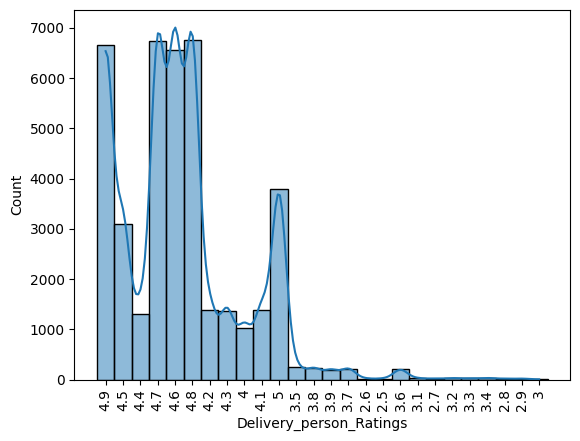

In [ ]:
sns.histplot(df["Delivery_person_Ratings"], kde = True, bins = 60)
plt.xticks(rotation = 90)

Looking at the target variable that is Time Taken, what could be the factors that are possibly affecting this target variable: Weather_conditions, road traffic, condition of vehicle , type of vehicle also if there are multiple deliveries , festival is there or not, it could cause unusual congestion on roads. Also the city.

In [ ]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [ ]:
df["Time_taken(min)"] = df["Time_taken(min)"].str.split(" ").str[1].astype(int)

In [ ]:
# looking at the time taken in each type of city
df.groupby("City")["Time_taken(min)"].mean()

,Time_taken(min)
City,
Metropolitian,27.429860
Semi-Urban,49.710526
Urban,23.209495


<Axes: xlabel='City', ylabel='Time_taken(min)'>

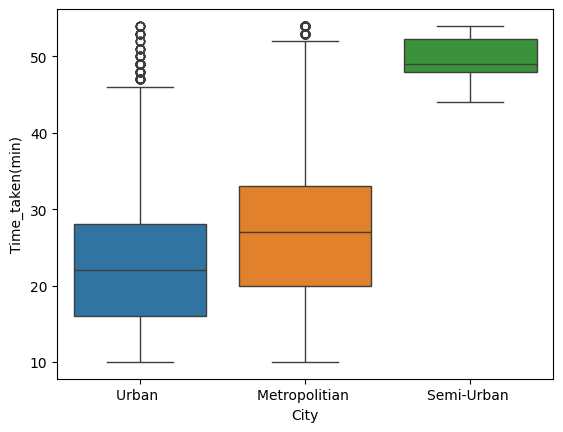

In [ ]:
sns.boxplot(df, x = df["City"], y = df["Time_taken(min)"], hue = "City")

We can observe that Semi-Urban cities have higher delivery times, due to obvious reasons, the facilities and warehouses are far away , conditions of roads are not good, no proper traffic management etc. So this feature has an impact on delivery time.

**Traffic density**

<Axes: xlabel='Road_traffic_density', ylabel='Time_taken(min)'>

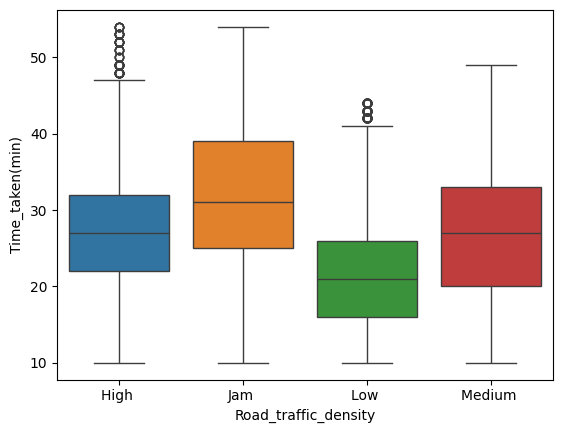

In [ ]:
# now looking at the traffic densities
sns.boxplot(df, x = df["Road_traffic_density"], y = df["Time_taken(min)"], hue = "Road_traffic_density")

We can observe that this feature also has a impact on delivery time

In [ ]:
# finding out the traffic density city wise
traffic_order = {"Low": 1, "Medium": 2, "High": 3, "Jam": 4}
df["Road_traffic_density"] = df["Road_traffic_density"].str.strip()
df["traffic_ordinal"] = df["Road_traffic_density"].map(traffic_order)

print(df.groupby("City")["traffic_ordinal"].max())

City
Metropolitian     4
Semi-Urban        4
Urban             4
Name: traffic_ordinal, dtype: int64


**Weather conditions**

<Axes: xlabel='Weatherconditions', ylabel='Time_taken(min)'>

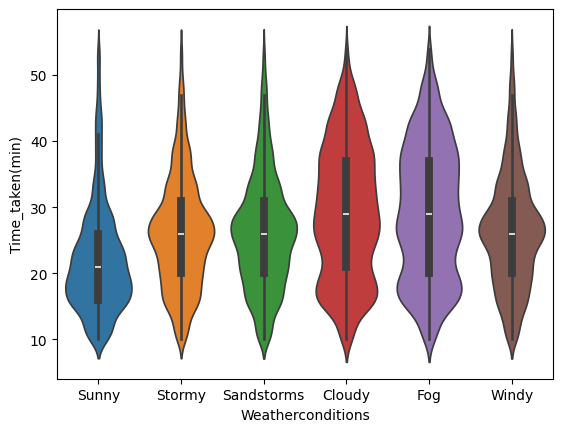

In [ ]:
sns.violinplot(df, x = df["Weatherconditions"], y = df["Time_taken(min)"], hue = "Weatherconditions")

So we can see that weather conditions do impact estimated delivery time. In sunny and cloudy weather time is relativesly lesser. howevery foggy weather conditions show a higher time of delivery.

**Multiple deliveries**

In [ ]:
df["multiple_deliveries"].unique()

array(['0', '1', '3', '2'], dtype=object)

'0': The delivery executive is carrying only this single order (zero extra deliveries).

'1': The delivery executive is carrying 1 additional order along the route.

'2': The delivery executive is carrying 2 additional orders along the route.

'3': The delivery executive is carrying 3 additional orders along the route (maximum load/batching).

<Axes: xlabel='multiple_deliveries', ylabel='Time_taken(min)'>

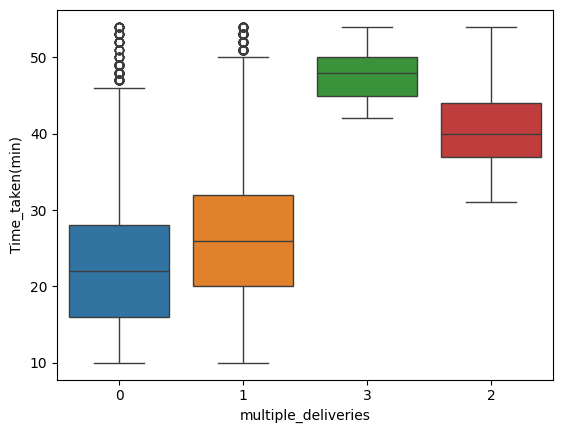

In [ ]:
# checking how having multiple deliveries impact the delivery time
sns.boxplot(df, x = df["multiple_deliveries"], y = df["Time_taken(min)"], hue = "multiple_deliveries")

So we can see this feature is also impacting the delivery time, with a higher delivery time associated with multiple deliveries.

Let's find out is there a relation with a delivery person too? Is there a person who is performing better under extreme uncontrollable condtions and delivering on time.

In [ ]:
u = df.groupby("Delivery_person_ID")["Time_taken(min)"].mean().sort_values(ascending = True).reset_index()

In [ ]:
u = u[0:20]

Finding out the average time of delivery during extreme weather conditions

In [ ]:
best_delivery_person = u["Delivery_person_ID"].tolist()

In [ ]:
filtered_df = df[df["Delivery_person_ID"].isin(best_delivery_person)]

Performance of top 20 in different weather conditions

In [ ]:

filtered_df.groupby(["Delivery_person_ID", "Weatherconditions"])["Time_taken(min)"].mean().reset_index()

,Delivery_person_ID,Weatherconditions,Time_taken(min)
0,AGRRES03DEL02,Cloudy,21.500000
1,AGRRES03DEL02,Fog,27.000000
2,AGRRES03DEL02,Sandstorms,15.500000
3,AGRRES03DEL02,Sunny,20.500000
4,AGRRES03DEL02,Windy,21.500000
...,...,...,...
87,LUDHRES18DEL02,Cloudy,18.000000
88,LUDHRES18DEL02,Fog,20.000000
89,LUDHRES18DEL02,Sandstorms,23.333333
90,LUDHRES18DEL02,Sunny,12.500000


In [ ]:
df.groupby("Weatherconditions")["Time_taken(min)"].mean().reset_index()

,Weatherconditions,Time_taken(min)
0,Cloudy,29.139281
1,Fog,29.174115
2,Sandstorms,26.113398
3,Stormy,26.110619
4,Sunny,22.143484
5,Windy,26.357070


So we can see that those 20 delivery persons are performing better than the normal people, these people are taking less than the average time. So, we can see that delivery person has an impact on the delivery time. They have lower average time.

**Finding the relation with the Vehicle condition**

0: Poor / Bad condition (often resulting in higher delivery times, as seen by the higher median in your plot).

1: Average / Fair condition.

2: Good / Excellent condition (associated with faster, more consistent delivery times).

<Axes: xlabel='Vehicle_condition', ylabel='Time_taken(min)'>

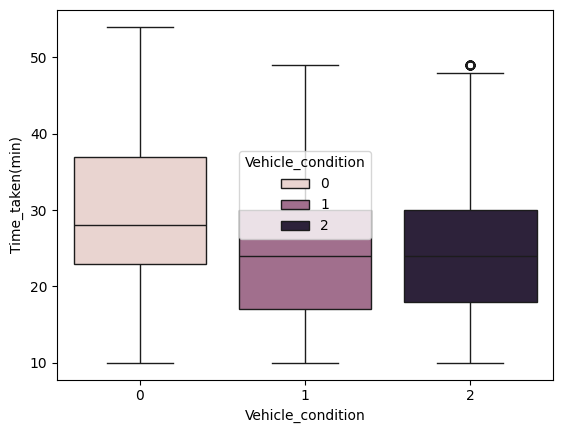

In [ ]:
sns.boxplot(df, x = df["Vehicle_condition"], y=df["Time_taken(min)"], hue = "Vehicle_condition")

**Type of Vehicle**

Weak correlation, maybe number of scooter users are lesser"

<Axes: xlabel='Type_of_vehicle', ylabel='Time_taken(min)'>

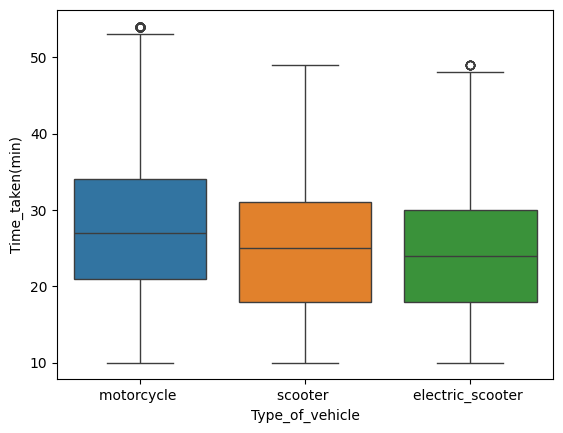

In [ ]:
sns.boxplot(df, x = df["Type_of_vehicle"], y=df["Time_taken(min)"], hue = "Type_of_vehicle")

**Heatmap**

In [ ]:

correl = df.select_dtypes(include = "number").corr()

<Axes: >

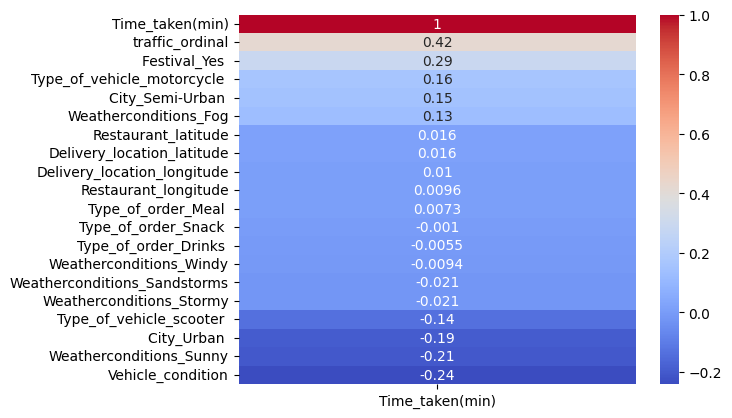

In [ ]:
df_encoded = df.copy()
df_encoded["traffic_ordinal"] = df["Road_traffic_density"].map(traffic_order)

cat_cols = ["Weatherconditions", "City", "Type_of_order", "Type_of_vehicle", "Festival"]
df_encoded = pd.get_dummies(df_encoded, columns=cat_cols, drop_first=True)

correl_full = df_encoded.select_dtypes(include=["number", "bool"]).corr(numeric_only=True)
sns.heatmap(correl_full[["Time_taken(min)"]].sort_values("Time_taken(min)", ascending=False),
            annot=True, cmap="coolwarm")

Restaurant and delivery locations showed a strong geographical alignment, indicating that proximity significantly affects delivery efficiency, further validated by correlation analyse

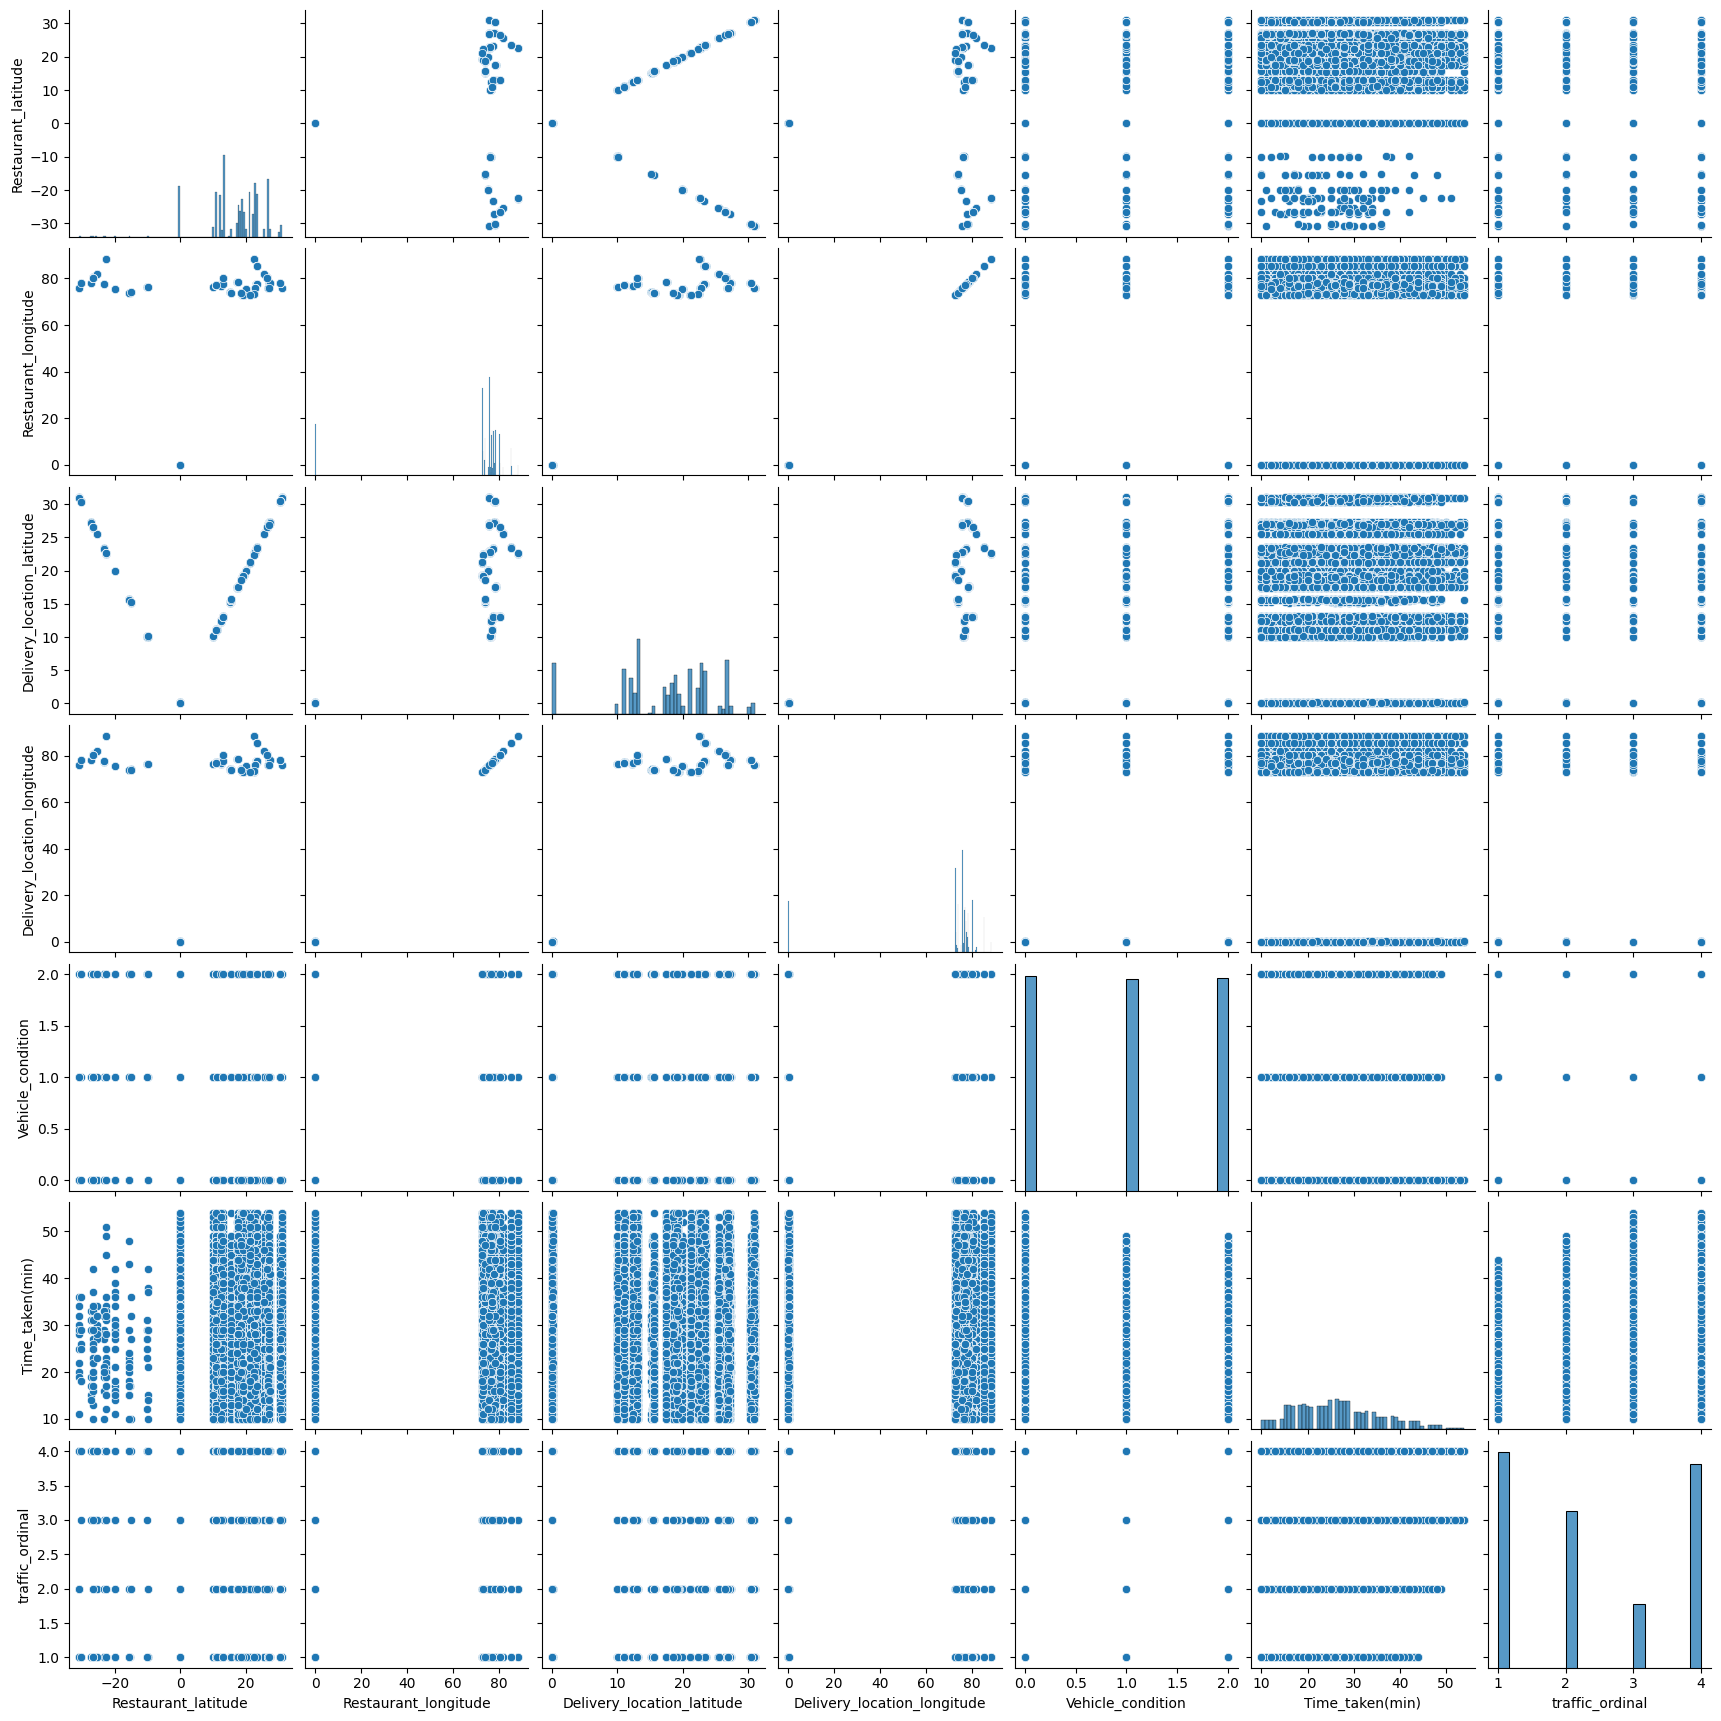

In [ ]:
sns.pairplot(df)

**Haversine formula**

We employed the haversine formula to compute the geospatial distance between restaurant and delivery locations, as geographic proximity was found to significantly impact delivery times during exploratory analysis.

In [ ]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)',
       'traffic_ordinal'],
      dtype='object')

In [ ]:
import numpy as np

def haversine(row):
    lat1, lon1 = np.radians(row['Restaurant_latitude']), np.radians(row['Restaurant_longitude'])
    lat2, lon2 = np.radians(row['Delivery_location_latitude']), np.radians(row['Delivery_location_longitude'])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return c * 6371.0

# Calculate distance for the entire dataset
df['distance_km'] = df.apply(haversine, axis=1)


In [ ]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),traffic_ordinal,distance_km
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,High,2,Snack,motorcycle,0,No,Urban,24,3,3.025149
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,Jam,2,Snack,scooter,1,No,Metropolitian,33,4,20.183530
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,Low,0,Drinks,motorcycle,1,No,Urban,26,1,1.552758
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,Medium,0,Buffet,motorcycle,1,No,Metropolitian,21,2,7.790401
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,High,1,Snack,scooter,1,No,Metropolitian,30,3,6.210138


In [ ]:
df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], format="%H:%M:%S", errors="coerce")
df["Time_Order_picked"] = pd.to_datetime(df["Time_Order_picked"], format="%H:%M:%S", errors="coerce")

prep_time = (df["Time_Order_picked"] - df["Time_Orderd"]).dt.total_seconds() / 60
prep_time = prep_time.where(prep_time >= 0, prep_time + 24 * 60)  # fix wraparound
df["prep_time_min"] = prep_time

([<matplotlib.axis.YTick at 0x7fb638d5ed50>,
 [Text(0, 0, '0'), Text(0, 1, '1')])

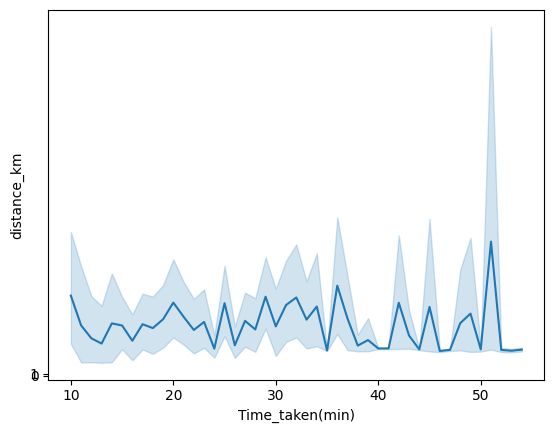

In [ ]:
sns.lineplot(x = df["Time_taken(min)"], y = df["distance_km"])
plt.yticks([0,1])

In [ ]:
print(df["distance_km"].describe())

count    41368.000000
mean        26.912063
std        298.782043
min          1.465067
25%          4.663601
50%          9.268782
75%         13.735969
max       6884.726399
Name: distance_km, dtype: float64


There are some outliers in this column

**Outlier Analysis**

In [ ]:
df = df[df["distance_km"] <= 30]

**Weather and traffic are correlated with each other**

<Axes: xlabel='Weatherconditions', ylabel='Road_traffic_density'>

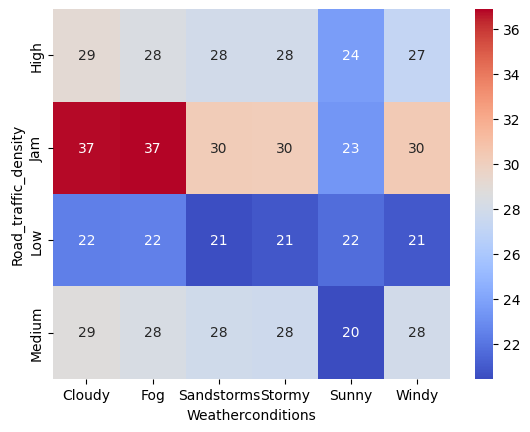

In [ ]:
pivot = df.pivot_table(values="Time_taken(min)", index="Road_traffic_density", columns="Weatherconditions", aggfunc="mean")
sns.heatmap(pivot, annot=True, cmap="coolwarm")

**Order at a particular hour of the day and time taken**

/tmp/ipykernel_948/1083156589.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["order_hour"] = df["Time_Orderd"].dt.hour


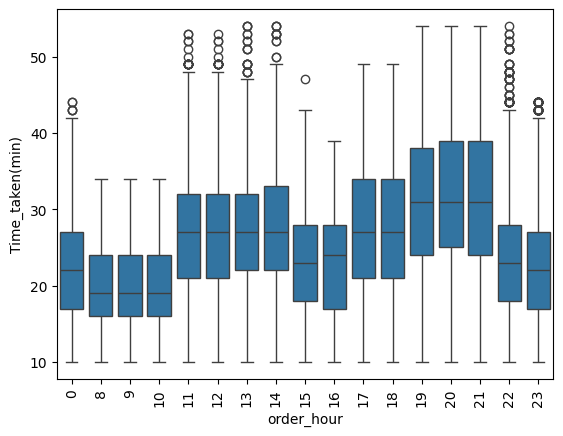

In [ ]:
df["order_hour"] = df["Time_Orderd"].dt.hour
sns.boxplot(x=df["order_hour"], y=df["Time_taken(min)"])
plt.xticks(rotation = 90)
plt.show()

In [ ]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)',
       'traffic_ordinal', 'distance_km', 'prep_time_min', 'order_hour'],
      dtype='object')

Festival
No      26.166654
Yes     45.518607
Name: Time_taken(min), dtype: float64


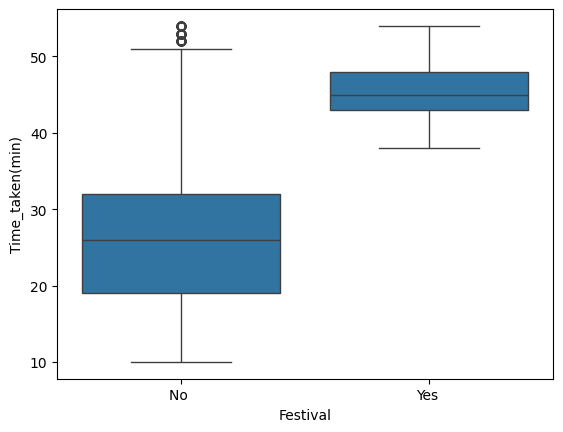

In [ ]:
sns.boxplot(x=df["Festival"], y=df["Time_taken(min)"])
print(df.groupby("Festival")["Time_taken(min)"].mean())

**Festival column**

In [ ]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)',
       'traffic_ordinal', 'distance_km', 'prep_time_min', 'order_hour'],
      dtype='object')

In [ ]:
df.groupby("Festival")["Time_taken(min)"].mean().reset_index()

,Festival,Time_taken(min)
0,No,26.166654
1,Yes,45.518607


We can clearly say that the time taken at time of festival is more as compared to the non-festive days.

/tmp/ipykernel_948/986373721.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Time_taken(min)"])


<Axes: xlabel='Time_taken(min)', ylabel='Density'>

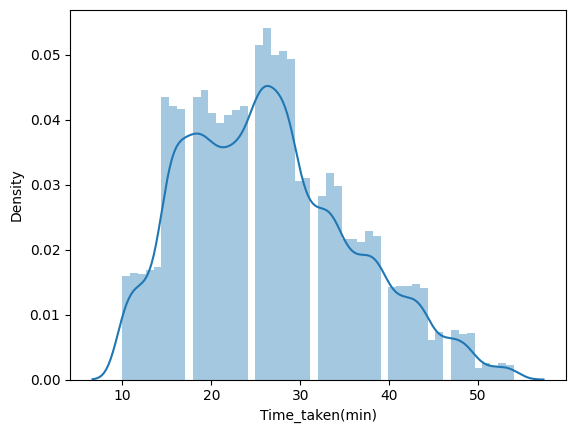

In [ ]:
sns.distplot(df["Time_taken(min)"])

#### **Model Fitting and Data Preprocessing**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
import lightgbm # Corrected import statement, as lightgbm is not part of sklearn
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

In [ ]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)',
       'traffic_ordinal', 'distance_km', 'prep_time_min', 'order_hour'],
      dtype='object')

In [ ]:
x_train = df[["Delivery_person_Age","Delivery_person_Ratings","Weatherconditions",
              "Road_traffic_density","Vehicle_condition","Type_of_order","Type_of_vehicle",
              "multiple_deliveries","Festival","City","distance_km","prep_time_min","order_hour"]]
y_train = df["Time_taken(min)"]

In [ ]:
# Apply missing value handling, consistent with training data (df)
test.replace(missing_symbols, np.nan, inplace=True)

# Drop rows with NaN values, consistent with training data (df)
test = test.dropna()

# Calculate distance_km using the globally defined haversine function
test['distance_km'] = test.apply(haversine, axis=1)

# Convert time columns and calculate prep_time_min
test["Time_Orderd"] = pd.to_datetime(test["Time_Orderd"], format="%H:%M:%S", errors="coerce")
test["Time_Order_picked"] = pd.to_datetime(test["Time_Order_picked"], format="%H:%M:%S", errors="coerce")
prep_time_test = (test["Time_Order_picked"] - test["Time_Orderd"]).dt.total_seconds() / 60
prep_time_test = prep_time_test.where(prep_time_test >= 0, prep_time_test + 24 * 60)
test["prep_time_min"] = prep_time_test

# Extract order_hour
test["order_hour"] = test["Time_Orderd"].dt.hour

x_test = test[["Delivery_person_Age","Delivery_person_Ratings","Weatherconditions",
              "Road_traffic_density","Vehicle_condition","Type_of_order","Type_of_vehicle",
              "multiple_deliveries","Festival","City","distance_km","prep_time_min","order_hour"]]

In [ ]:
obj_cols = x_train.select_dtypes(include='object').columns

for col in obj_cols:
    x_train[col] = x_train[col].str.strip()
    x_test[col] = x_test[col].str.strip()

# Sanity check — confirm no more stray whitespace anywhere
for col in obj_cols:
    print(col, x_train[col].apply(repr).unique())
    print(col, x_test[col].apply(repr).unique())

Delivery_person_Age ["'37'" "'34'" "'23'" "'38'" "'32'" "'22'" "'33'" "'35'" "'36'" "'21'"
 "'24'" "'29'" "'25'" "'31'" "'27'" "'26'" "'20'" "'28'" "'39'" "'30'"]
Delivery_person_Age ["'28'" "'23'" "'21'" "'31'" "'26'" "'35'" "'24'" "'33'" "'36'" "'34'"
 "'38'" "'37'" "'30'" "'22'" "'29'" "'20'" "'39'" "'27'" "'25'" "'32'"]
Delivery_person_Ratings ["'4.9'" "'4.5'" "'4.4'" "'4.7'" "'4.6'" "'4.8'" "'4.2'" "'4.3'" "'4'"
 "'4.1'" "'5'" "'3.5'" "'3.8'" "'3.9'" "'3.7'" "'2.6'" "'2.5'" "'3.6'"
 "'3.1'" "'2.7'" "'3.2'" "'3.3'" "'3.4'" "'2.8'" "'2.9'" "'3'"]
Delivery_person_Ratings ["'4.6'" "'4.5'" "'4.8'" "'4.7'" "'4.9'" "'4.2'" "'2.7'" "'5'" "'4.3'"
 "'3.8'" "'4.1'" "'4.4'" "'3.9'" "'4'" "'3.7'" "'3.5'" "'2.8'" "'3.3'"
 "'3.4'" "'3.2'" "'3.6'" "'2.6'" "'2.9'" "'2.5'" "'3.1'" "'3'"]
Weatherconditions ["'Sunny'" "'Stormy'" "'Sandstorms'" "'Cloudy'" "'Fog'" "'Windy'"]
Weatherconditions ["'Windy'" "'Stormy'" "'Fog'" "'Sunny'" "'Cloudy'" "'Sandstorms'"]
Road_traffic_density ["'High'" "'Jam'" "'Low

/tmp/ipykernel_948/2752374515.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train[col] = x_train[col].str.strip()
/tmp/ipykernel_948/2752374515.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test[col] = x_test[col].str.strip()


In [ ]:
from sklearn.model_selection import train_test_split

x_train_split, x_val, y_train_split, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

In [ ]:
x_train.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'distance_km', 'prep_time_min', 'order_hour'],
      dtype='object')

Confirming the data type of ID

In [ ]:
print(x_train['Delivery_person_Age'].dtype)
x_train['Delivery_person_Age'] = x_train['Delivery_person_Age'].astype(int)
x_test['Delivery_person_Age'] = x_test['Delivery_person_Age'].astype(int)

object


/tmp/ipykernel_948/2130420675.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train['Delivery_person_Age'] = x_train['Delivery_person_Age'].astype(int)
/tmp/ipykernel_948/2130420675.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test['Delivery_person_Age'] = x_test['Delivery_person_Age'].astype(int)


Now, we earlier found out the major dependence on the delivery person that is there were people who were performing better than the average time, so there is a dependence on skill

In [ ]:
x_train.head()

,Delivery_person_Age,Delivery_person_Ratings,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,distance_km,prep_time_min,order_hour
0,37,4.9,Sunny,High,2,Snack,motorcycle,0,No,Urban,3.025149,15.0,11
1,34,4.5,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,20.183530,5.0,19
2,23,4.4,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,1.552758,15.0,8
3,38,4.7,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,7.790401,10.0,18
4,32,4.6,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,6.210138,15.0,13


In [ ]:
step1 = ColumnTransformer(transformers = [
    ("col tnf", OneHotEncoder(sparse_output = False, drop = "first"), [2,5,6,8,9]),
    ("col tnf2", OrdinalEncoder(categories = [["Low", "Medium", "High", "Jam"]]), [3])
], remainder = "passthrough")

step2 = LinearRegression()

pipe = Pipeline([
    ("step1", step1),
    ("step2", step2)
])

pipe.fit(x_train_split, y_train_split)
y_val_pred = pipe.predict(x_val)

print("R2 score", r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

R2 score 0.5989731042239194
MAE 4.725689154732003


**Ridge regression**

In [ ]:
step1 = ColumnTransformer(transformers = [
    ("col tnf", OneHotEncoder(sparse_output = False, drop = "first"), [2,5,6,8,9]),
    ("col tnf2", OrdinalEncoder(categories = [["Low", "Medium", "High", "Jam"]]), [3])
], remainder = "passthrough")

step2 = Ridge(alpha = 10)

pipe = Pipeline([
    ("step1", step1),
    ("step2", step2)
])

pipe.fit(x_train_split, y_train_split)
y_val_pred = pipe.predict(x_val)

print("R2 score", r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

R2 score 0.5987903042956977
MAE 4.726832497681209


**Finding optimal alpha values**

In [ ]:
a_values = np.arange(1,20)
mae = []
for i in a_values:
  pipe.set_params(step2__alpha=i)
  pipe.fit(x_train_split,y_train_split)
  y_pred = pipe.predict(x_val)
  mae.append(mean_absolute_error(y_val,y_pred))
mae

[4.7257944004995895,
 4.725913726647759,
 4.726032076801179,
 4.72614901322309,
 4.726264661162558,
 4.726380920639082,
 4.726495773501872,
 4.726609227885057,
 4.726721337279025,
 4.726832497681209,
 4.726942310486377,
 4.727051249152193,
 4.72715861282404,
 4.727264435382799,
 4.727383769418733,
 4.727505726019435,
 4.7276263245907835,
 4.727746156668039,
 4.7278648527013]

<Axes: >

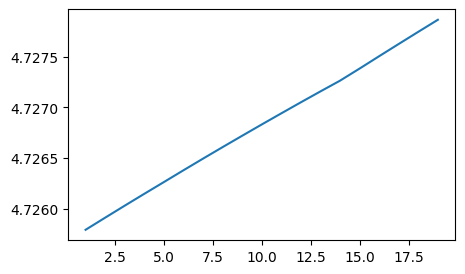

In [ ]:
plt.figure(figsize = (5,3))
sns.lineplot(x=a_values, y=mae)

**Lasso Regression**

In [ ]:
step1 = ColumnTransformer(transformers = [
    ("col tnf", OneHotEncoder(sparse_output = False, drop = "first"), [2,5,6,8,9]),
    ("col tnf2", OrdinalEncoder(categories = [["Low", "Medium", "High", "Jam"]]), [3])
], remainder = "passthrough")

step2 = Lasso(alpha = 0.001)

pipe = Pipeline([
    ("step1", step1),
    ("step2", step2)
])

pipe.fit(x_train_split, y_train_split)
y_val_pred = pipe.predict(x_val)

print("R2 score", r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

R2 score 0.5989180809688839
MAE 4.725901842610754


**KNN**

In [ ]:
step1 = ColumnTransformer(transformers = [
    ("col tnf", OneHotEncoder(sparse_output = False, drop = "first"), [2,5,6,8,9]),
    ("col tnf2", OrdinalEncoder(categories = [["Low", "Medium", "High", "Jam"]]), [3])
], remainder = "passthrough")

step2 = KNeighborsRegressor(n_neighbors = 8)

pipe = Pipeline([
    ("step1", step1),
    ("step2", step2)
])

pipe.fit(x_train_split, y_train_split)
y_val_pred = pipe.predict(x_val)

print("R2 score", r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

R2 score 0.5729920728539907
MAE 4.799696785930867


In [ ]:
k_values = np.arange(1,11)
mae = []
for i in k_values:
  pipe.set_params(step2__n_neighbors=i)
  pipe.fit(x_train_split,y_train_split)
  y_pred = pipe.predict(x_val)
  mae.append(mean_absolute_error(y_val,y_pred))
mae

[5.655548817465131,
 5.035112189205579,
 4.9047907822923,
 4.799757428744694,
 4.779769557307459,
 4.782757226601981,
 4.7940223512085245,
 4.799696785930867,
 4.812991038339734,
 4.822534869617949]

**Decision Tree**

In [ ]:
step1 = ColumnTransformer(transformers = [
    ("col tnf", OneHotEncoder(sparse_output = False, drop = "first"), [2,5,6,8,9]),
    ("col tnf2", OrdinalEncoder(categories = [["Low", "Medium", "High", "Jam"]]), [3])
], remainder = "passthrough")

step2 = DecisionTreeRegressor(max_depth = 10)

pipe = Pipeline([
    ("step1", step1),
    ("step2", step2)
])

pipe.fit(x_train_split, y_train_split)
y_val_pred = pipe.predict(x_val)

print("R2 score", r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

R2 score 0.7768125179806555
MAE 3.482467527431561


**SVM**

In [ ]:
from sklearn.svm import SVR

In [ ]:
step1 = ColumnTransformer(transformers = [
    ("col tnf", OneHotEncoder(sparse_output = False, drop = "first"), [2,5,6,8,9]),
    ("col tnf2", OrdinalEncoder(categories = [["Low", "Medium", "High", "Jam"]]), [3])
], remainder = "passthrough")

step2 = SVR(kernel='rbf',C=100,epsilon=0.1)

pipe = Pipeline([
    ("step1", step1),
    ("step2", step2)
])

pipe.fit(x_train_split, y_train_split)
y_val_pred = pipe.predict(x_val)

print("R2 score", r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

R2 score 0.6857061567291987
MAE 4.124749688468148


**Random Forest**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
step1 = ColumnTransformer(transformers = [
    ("col tnf", OneHotEncoder(sparse_output = False, drop = "first"), [2,5,6,8,9]),
    ("col tnf2", OrdinalEncoder(categories = [["Low", "Medium", "High", "Jam"]]), [3])
], remainder = "passthrough")

step2 = RandomForestRegressor(n_estimators=100,
                              random_state=3,
                              max_samples=0.5,
                              max_features=0.75,
                              max_depth=15)

pipe = Pipeline([
    ("step1", step1),
    ("step2", step2)
])

param_dist = {
    "step2__n_estimators": [100, 200, 300, 500],
    "step2__max_depth": [10, 15, 20, 25, None],
    "step2__min_samples_split": [2, 5, 10],
    "step2__min_samples_leaf": [1, 2, 4],
    "step2__max_features": [0.5, 0.75, "sqrt", "log2"],
    "step2__max_samples": [0.5, 0.7, 0.9, None]
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(x_train_split, y_train_split)
best_pipe = search.best_estimator_
y_val_pred = best_pipe.predict(x_val)

print("R2 score", r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
R2 score 0.839695813985561
MAE 3.0005793749139835


**Using Optuna for Hyperparameter Tuning**

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 28.2 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=50),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", [0.5, 0.75, "sqrt", "log2"]),
        "max_samples": trial.suggest_float("max_samples", 0.4, 1.0),
    }

    step2 = RandomForestRegressor(random_state=3, n_jobs=-1, **params)

    pipe = Pipeline([
        ("step1", step1),
        ("step2", step2)
    ])

    scores = cross_val_score(
        pipe, x_train_split, y_train_split,
        cv=3,                              # keep folds low — each trial refits from scratch
        scoring="neg_mean_absolute_error",
        n_jobs=1                           # RF already parallelizes internally via n_jobs=-1 above
    )
    return -scores.mean()  # Optuna minimizes by default, so return positive MAE

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("Best MAE:", study.best_value)
print("Best params:", study.best_params)

[I 2026-09-26 13:29:11,012] A new study created in memory with name: no-name-0ca154ba-1b99-465d-a890-945ed2a4d725


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-09-26 13:29:37,148] Trial 0 finished with value: 3.459675985802853 and parameters: {'n_estimators': 600, 'max_depth': 11, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_samples': 0.702994767353166}. Best is trial 0 with value: 3.459675985802853.
[I 2026-09-26 13:29:43,418] Trial 1 finished with value: 3.210866978143206 and parameters: {'n_estimators': 100, 'max_depth': 26, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_samples': 0.8559500349018819}. Best is trial 1 with value: 3.210866978143206.
[I 2026-09-26 13:29:56,328] Trial 2 finished with value: 3.0576249271090226 and parameters: {'n_estimators': 150, 'max_depth': 18, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_samples': 0.7868002618498149}. Best is trial 2 with value: 3.0576249271090226.
[I 2026-09-26 13:30:01,807] Trial 3 finished with value: 3.9883256973923262 and parameters: {'n_estimators': 100, 'max_depth': 6, 'min_samples_split'

In [ ]:
best_params = study.best_params
step2 = RandomForestRegressor(random_state=3, n_jobs=-1, **best_params)

pipe = Pipeline([
    ("step1", step1),
    ("step2", step2)
])

pipe.fit(x_train_split, y_train_split)
y_val_pred = pipe.predict(x_val)

print("R2 score", r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

R2 score 0.841600064167953
MAE 2.9877097334870726


**Adaboost**

In [ ]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 10, 200, step=10),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 2.0, log=True),
        "loss": trial.suggest_categorical("loss", ["linear", "square", "exponential"]),
    }

    step2 = AdaBoostRegressor(random_state=3, **params)

    pipe = Pipeline([
        ("step1", step1),
        ("step2", step2)
    ])

    scores = cross_val_score(
        pipe, x_train_split, y_train_split,
        cv=3,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )
    return -scores.mean()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("Best MAE:", study.best_value)
print("Best params:", study.best_params)

[I 2026-09-26 13:50:20,204] A new study created in memory with name: no-name-ccac24a2-6bf6-4e25-9228-6e8e2d953286


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-09-26 13:50:30,758] Trial 0 finished with value: 5.3422664513585465 and parameters: {'n_estimators': 30, 'learning_rate': 0.006108166884695588, 'loss': 'linear'}. Best is trial 0 with value: 5.3422664513585465.
[I 2026-09-26 13:51:01,960] Trial 1 finished with value: 5.306812539294163 and parameters: {'n_estimators': 120, 'learning_rate': 0.007065751158768298, 'loss': 'exponential'}. Best is trial 1 with value: 5.306812539294163.
[I 2026-09-26 13:51:19,800] Trial 2 finished with value: 4.776798641199595 and parameters: {'n_estimators': 70, 'learning_rate': 1.6761537450727189, 'loss': 'exponential'}. Best is trial 2 with value: 4.776798641199595.
[I 2026-09-26 13:51:22,532] Trial 3 finished with value: 5.176258013404692 and parameters: {'n_estimators': 10, 'learning_rate': 0.08798218361745282, 'loss': 'square'}. Best is trial 2 with value: 4.776798641199595.
[I 2026-09-26 13:52:08,221] Trial 4 finished with value: 4.764099369263195 and parameters: {'n_estimators': 180, 'learning

In [ ]:
best_params = study.best_params
step2 = AdaBoostRegressor(random_state=3, **best_params)

pipe = Pipeline([
    ("step1", step1),
    ("step2", step2)
])

pipe.fit(x_train_split, y_train_split)
y_val_pred = pipe.predict(x_val)

print("R2 score", r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

R2 score 0.623630956745897
MAE 4.645703240824153


**Gradient Boosting**

In [ ]:
step1 = ColumnTransformer(transformers = [
    ("col tnf", OneHotEncoder(sparse_output = False, drop = "first"), [2,5,6,8,9]),
    ("col tnf2", OrdinalEncoder(categories = [["Low", "Medium", "High", "Jam"]]), [3])
], remainder = "passthrough")

step2 = GradientBoostingRegressor(n_estimators=500)

pipe = Pipeline([
    ("step1", step1),
    ("step2", step2)
])

pipe.fit(x_train_split, y_train_split)
y_val_pred = pipe.predict(x_val)

print("R2 score", r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

R2 score 0.8059886228810934
MAE 3.2985537375312366


**Xgboost**

In [ ]:
pip install xgboost

In [ ]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
    }

    step2 = XGBRegressor(random_state=3, n_jobs=-1, **params)

    pipe = Pipeline([
        ("step1", step1),
        ("step2", step2)
    ])

    scores = cross_val_score(
        pipe, x_train_split, y_train_split,
        cv=3,
        scoring="neg_mean_absolute_error",
        n_jobs=1        # avoid nested parallelism — XGBoost already parallelizes internally
    )
    return -scores.mean()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("Best MAE:", study.best_value)
print("Best params:", study.best_params)

[I 2026-09-26 14:02:47,837] A new study created in memory with name: no-name-1067a508-16e5-472c-bcf4-f8b76db981bf


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-09-26 14:03:07,321] Trial 0 finished with value: 3.3068483670552573 and parameters: {'n_estimators': 350, 'max_depth': 9, 'learning_rate': 0.13298271760001595, 'subsample': 0.7129076596514674, 'colsample_bytree': 0.5313123708071257, 'min_child_weight': 8, 'gamma': 0.860616716435656, 'reg_alpha': 0.5365177050512587, 'reg_lambda': 2.1280468753225827}. Best is trial 0 with value: 3.3068483670552573.
[I 2026-09-26 14:03:14,762] Trial 1 finished with value: 3.229660669962565 and parameters: {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.09393950623040075, 'subsample': 0.7025733971310733, 'colsample_bytree': 0.5804370588382735, 'min_child_weight': 10, 'gamma': 4.525031761039124, 'reg_alpha': 3.427656374051176, 'reg_lambda': 1.1052147600034763}. Best is trial 1 with value: 3.229660669962565.
[I 2026-09-26 14:03:27,878] Trial 2 finished with value: 3.3162178993225098 and parameters: {'n_estimators': 750, 'max_depth': 10, 'learning_rate': 0.11631104293236241, 'subsample': 0.5

In [ ]:
best_params = study.best_params
step2 = XGBRegressor(random_state=3, n_jobs=-1, **best_params)

pipe = Pipeline([
    ("step1", step1),
    ("step2", step2)
])

pipe.fit(x_train_split, y_train_split)
y_val_pred = pipe.predict(x_val)

print("R2 score", r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

R2 score 0.8403078317642212
MAE 2.991025447845459


**Stacking**

In [ ]:
from sklearn.ensemble import VotingRegressor,StackingRegressor

step1 = ColumnTransformer(transformers = [
    ("col tnf", OneHotEncoder(sparse_output = False, drop = "first"), [2,5,6,8,9]),
    ("col tnf2", OrdinalEncoder(categories = [["Low", "Medium", "High", "Jam"]]), [3])
], remainder = "passthrough")

estimators = [
    ('rf', RandomForestRegressor(n_estimators=350,random_state=3,max_samples=0.5,max_features=0.75,max_depth=15)),
    ('gbdt',GradientBoostingRegressor(n_estimators=100,max_features=0.5)),
    ('xgb', XGBRegressor(n_estimators=25,learning_rate=0.3,max_depth=5))
]

step2 = StackingRegressor(estimators=estimators, final_estimator=KNeighborsRegressor(n_neighbors = 8))

pipe = Pipeline([
    ("step1", step1),
    ("step2", step2)
])

pipe.fit(x_train_split, y_train_split)
y_val_pred = pipe.predict(x_val)

print("R2 score", r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

R2 score 0.8247083975727583
MAE 3.1021679805942997


**LightGBM**

In [ ]:
from lightgbm import LGBMRegressor

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "num_leaves": trial.suggest_int("num_leaves", 15, 150),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
    }

    step2 = LGBMRegressor(random_state=3, n_jobs=-1, verbose=-1, **params)

    pipe = Pipeline([
        ("step1", step1),
        ("step2", step2)
    ])

    scores = cross_val_score(
        pipe, x_train_split, y_train_split,
        cv=3,
        scoring="neg_mean_absolute_error",
        n_jobs=1        # avoid nested parallelism — LightGBM already parallelizes internally
    )
    return -scores.mean()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("Best MAE:", study.best_value)
print("Best params:", study.best_params)

[I 2026-09-26 14:11:31,124] A new study created in memory with name: no-name-59dc79a4-94d0-4c05-b6bb-f2f6ee4b4f0c


  0%|          | 0/40 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[I 2026-09-26 14:11:32,534] Trial 0 finished with value: 3.096857390859963 and parameters: {'n_estimators': 100, 'max_depth': 8, 'num_leaves': 57, 'learning_rate': 0.2173536113399503, 'subsample': 0.8751336964224203, 'colsample_bytree': 0.6443251857300434, 'min_child_samples': 43, 'reg_alpha': 0.9918377570734721, 'reg_lambda': 3.3206061916454055}. Best is trial 0 with value: 3.096857390859963.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

[I 2026-09-26 14:15:52,942] Trial 37 finished with value: 3.0228707700457877 and parameters: {'n_estimators': 750, 'max_depth': 11, 'num_leaves': 97, 'learning_rate': 0.015557936696218543, 'subsample': 0.7279698850498403, 'colsample_bytree': 0.8757430885401536, 'min_child_samples': 24, 'reg_alpha': 0.7268631789666342, 'reg_lambda': 0.9156173927452298}. Best is trial 36 with value: 3.0191681964991175.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[I 2026-09-26 14:16:04,456] Trial 38 finished with value: 3.039160932685857 and parameters: {'n_estimators': 750, 'max_depth': 9, 'num_leaves': 78, 'learning_rate': 0.011379457722220739, 'subsample': 0.543571875222808, 'colsample_bytree': 0.8666356840584636, 'min_child_samples': 36, 'reg_alpha': 1.0370391153845726, 'reg_lambda': 0.8160961615677437}. Best is trial 36 with value: 3.0191681964991175.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[I 2026-09-26 14:16:14,687] Trial 39 finished with value: 3.018527289832767 and parameters: {'n_estimators': 700, 'max_depth': 11, 'num_leaves': 99, 'learning_rate': 0.013216503037651572, 'subsample': 0.740566041930255, 'colsample_bytree': 0.8517375843917331, 'min_child_samples': 20, 'reg_alpha': 0.1210644016416838, 'reg_lambda': 0.9839970178023912}. Best is trial 39 with value: 3.018527289832767.
Best MAE: 3.018527289832767
Best params: {'n_estimators': 700, 'max_depth': 11, 'num_leaves': 99, 'learning_rate': 0.013216503037651572, 'subsample': 0.740566041930255, 'colsample_bytree': 0.8517375843917331, 'min_child_samples': 20, 'reg_alpha': 0.1210644016416838, 'reg_lambda': 0.9839970178023912}


In [ ]:
best_params = study.best_params
step2 = LGBMRegressor(random_state=3, n_jobs=-1, verbose=-1, **best_params)

pipe = Pipeline([
    ("step1", step1),
    ("step2", step2)
])

pipe.fit(x_train_split, y_train_split)
y_val_pred = pipe.predict(x_val)

print("R2 score", r2_score(y_val, y_val_pred))
print("MAE", mean_absolute_error(y_val, y_val_pred))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


R2 score 0.8435301504963715
MAE 2.9692213482063967


**Final prediction on given test dataset**

In [ ]:
best_params = study.best_params  # from your LightGBM Optuna study
final_step2 = LGBMRegressor(random_state=3, n_jobs=-1, verbose=-1, **best_params)

final_pipe = Pipeline([
    ("step1", step1),
    ("step2", final_step2)
])

final_pipe.fit(x_train, y_train)
final_predictions = final_pipe.predict(x_test)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(final_pipe, x_train, y_train, cv=5, scoring="r2")
print("R2 across folds:", scores)
print("Mean:", scores.mean(), "Std:", scores.std())

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


R2 across folds: [0.84474762 0.84157648 0.84355188 0.83910843 0.84470315]
Mean: 0.8427375121016516 Std: 0.0021487534757961523


In [ ]:
import pandas as pd

feature_names = final_pipe.named_steps["step1"].get_feature_names_out()
importances = final_pipe.named_steps["step2"].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(feat_imp.head(15))

remainder__distance_km                   14981
remainder__Delivery_person_Age            7876
remainder__Delivery_person_Ratings        7267
remainder__order_hour                     5541
col tnf2__Road_traffic_density            4511
remainder__Vehicle_condition              4333
remainder__multiple_deliveries            3088
col tnf__Weatherconditions_Sandstorms     2414
col tnf__Weatherconditions_Windy          2408
remainder__prep_time_min                  2393
col tnf__Weatherconditions_Sunny          2385
col tnf__Weatherconditions_Stormy         2343
col tnf__City_Urban                       1893
col tnf__Weatherconditions_Fog            1861
col tnf__Festival_Yes                     1088
dtype: int32


In [ ]:
import joblib
joblib.dump(final_pipe, "lgbm_final_pipeline.pkl")

['lgbm_final_pipeline.pkl']